In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Train.csv")

In [6]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [7]:
df.groupby("Warehouse_block")["Warehouse_block"].count()

Warehouse_block
A    1833
B    1833
C    1833
D    1834
F    3666
Name: Warehouse_block, dtype: int64

In [8]:
df.groupby("Product_importance")["Cost_of_the_Product"].mean()

Product_importance
high      203.871308
low       212.059845
medium    209.382415
Name: Cost_of_the_Product, dtype: float64

In [9]:
df.groupby("Gender")["Discount_offered"].sum()

Gender
F    75204
M    71888
Name: Discount_offered, dtype: int64

In [10]:
(df["Reached.on.Time_Y.N"] == 0).mean() * 100

np.float64(40.33093917628875)

In [11]:
df.groupby(["Warehouse_block","Mode_of_Shipment"])["Reached.on.Time_Y.N"].value_counts()

Warehouse_block  Mode_of_Shipment  Reached.on.Time_Y.N
A                Flight            1                       174
                                   0                       123
                 Road              1                       168
                                   0                       126
                 Ship              1                       733
                                   0                       509
B                Flight            1                       177
                                   0                       119
                 Road              1                       172
                                   0                       122
                 Ship              1                       755
                                   0                       488
C                Flight            1                       184
                                   0                       111
                 Road              1                       169


In [12]:
df.groupby(["Mode_of_Shipment","Product_importance"])["Discount_offered"].mean()

Mode_of_Shipment  Product_importance
Flight            high                  13.325153
                  low                   12.572792
                  medium                13.761598
Road              high                  13.822785
                  low                   12.971995
                  medium                13.056376
Ship              high                  15.228070
                  low                   13.169350
                  medium                13.514692
Name: Discount_offered, dtype: float64

In [13]:
df[(df["Product_importance"]=="high") & 
   (df["Reached.on.Time_Y.N"]==0)]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
3137,3138,F,Road,4,3,161,3,high,M,7,4245,0
3145,3146,F,Road,3,5,136,2,high,F,1,4971,0
3147,3148,B,Flight,4,2,272,3,high,F,6,4559,0
3153,3154,B,Flight,3,2,153,10,high,M,2,5455,0
3159,3160,B,Flight,3,1,162,8,high,F,10,5429,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10609,10610,F,Ship,4,4,233,2,high,F,1,5320,0
10631,10632,F,Ship,4,2,230,3,high,F,5,5888,0
10672,10673,C,Road,5,2,258,5,high,M,6,1059,0
10834,10835,C,Flight,2,4,114,5,high,M,3,4423,0


In [14]:
df[df["Weight_in_gms"] > 5000]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
198,199,D,Ship,2,3,142,3,medium,F,38,7640,1
199,200,F,Ship,2,2,154,3,medium,M,38,7846,1
205,206,F,Ship,2,3,145,3,medium,F,24,7588,1
213,214,B,Ship,2,5,160,3,medium,F,31,7401,1
244,245,C,Ship,2,1,142,3,medium,F,8,6064,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10954,10955,C,Road,4,1,261,3,low,F,8,5206,1
10955,10956,F,Flight,2,5,125,4,low,M,5,5866,0
10958,10959,A,Flight,5,2,264,8,high,M,2,5252,1
10961,10962,F,Flight,3,2,164,4,medium,M,6,5761,0


In [15]:
df[(df["Cost_of_the_Product"]>200) & 
   (df["Discount_offered"]>40)]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
15,16,B,Flight,4,3,227,3,low,F,45,2707,1
21,22,B,Ship,3,1,232,4,medium,F,51,2899,1
28,29,C,Ship,2,3,234,4,low,M,44,3134,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3104,3105,A,Ship,2,2,273,3,low,M,56,2633,1
3111,3112,B,Ship,5,4,229,2,medium,F,44,2419,1
3126,3127,D,Road,3,1,224,3,low,F,48,3672,1
3130,3131,C,Road,6,5,246,4,medium,M,50,3618,1


In [16]:
pd.pivot_table(df,
               values="Reached.on.Time_Y.N",
               index="Warehouse_block",
               columns="Mode_of_Shipment",
               aggfunc="count")

Mode_of_Shipment,Flight,Road,Ship
Warehouse_block,,,
A,297,294,1242
B,296,294,1243
C,295,294,1244
D,297,292,1245
F,592,586,2488


In [17]:
pd.pivot_table(df,
               values="Cost_of_the_Product",
               index="Warehouse_block",
               columns="Product_importance",
               aggfunc="mean")

Product_importance,high,low,medium
Warehouse_block,,,
A,204.357576,209.801980,208.487484
B,199.390411,214.409357,212.087740
C,198.803571,214.636156,210.016435
D,212.222892,211.915062,209.496815
F,204.000000,210.888514,208.019534


In [18]:
pd.pivot_table(df,
               values="Discount_offered",
               index=["Warehouse_block","Mode_of_Shipment"],
               columns="Product_importance",
               aggfunc="mean")

Product_importance                     high        low     medium
Warehouse_block Mode_of_Shipment                                 
A               Flight            14.322581  11.868056  14.122951
                Road              16.222222  13.131034  12.524590
                Ship              16.691589  13.793548  11.947573
B               Flight            14.520000  10.672000  13.890411
                Road              12.172414  12.863636  13.398496
                Ship              15.467391  13.050167  13.358047
C               Flight            12.361111  13.588235  11.878049
                Road              14.481481  14.367347  12.825000
                Ship              13.695238  12.656514  14.321168
D               Flight             9.333333  13.376712  13.748031
                Road              15.160000  12.902098  11.491935
                Ship              13.794872  12.772727  13.559925
F               Flight            14.808511  12.864111  14.422481
                Road              12.460000  12.268966  14.036585
                Ship              15.956311  13.355296  13.909511

In [19]:
df.groupby("Reached.on.Time_Y.N")["Discount_offered"].mean()

Reached.on.Time_Y.N
0     5.545987
1    18.663721
Name: Discount_offered, dtype: float64

In [20]:
df.corr(numeric_only=True)

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,1.000000,0.188998,-0.005722,0.196791,0.145369,-0.598278,0.278312,-0.411822
Customer_care_calls,0.188998,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,-0.005722,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.196791,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.145369,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.598278,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,0.278312,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.411822,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


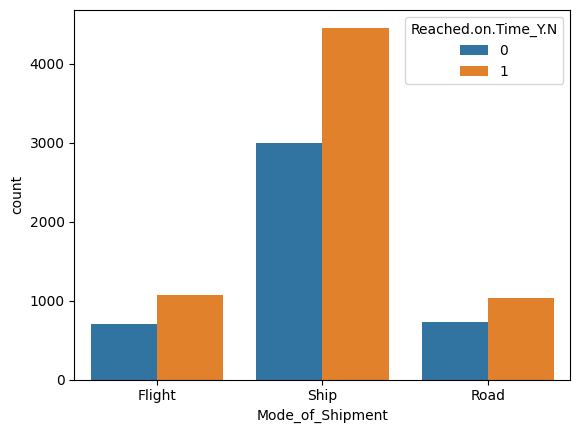

In [21]:
sns.countplot(x="Mode_of_Shipment",
              hue="Reached.on.Time_Y.N",
              data=df)
plt.show()

In [22]:
late_rate = df.groupby("Warehouse_block")["Reached.on.Time_Y.N"] \
              .apply(lambda x: (x==0).mean()*100)

late_rate.sort_values(ascending=False)

Warehouse_block
A    41.352973
C    40.316421
D    40.239913
F    40.152755
B    39.770867
Name: Reached.on.Time_Y.N, dtype: float64

In [23]:
cube = df.groupby(
    ["Warehouse_block",
     "Mode_of_Shipment",
     "Product_importance"]
)["Cost_of_the_Product"].agg(["sum","mean","count"])

cube

sum        mean  count
Warehouse_block Mode_of_Shipment Product_importance                           
A               Flight           high                  6229  200.935484     31
                                 low                  30127  209.215278    144
                                 medium               26025  213.319672    122
                Road             high                  5529  204.777778     27
                                 low                  30294  208.924138    145
                                 medium               25114  205.852459    122
                Ship             high                 21961  205.242991    107
                                 low                 130289  210.143548    620
                                 medium              107103  207.966990    515
B               Flight           high                  5261  210.440000     25
                                 low                  26762  214.096000    125
                                 medium               30417  208.335616    146
                Road             high                  5677  195.758621     29
                                 low                  28447  215.507576    132
                                 medium               28590  214.962406    133
                Ship             high                 18173  197.532609     92
                                 low                 128111  214.232441    598
                                 medium              117450  212.386980    553
C               Flight           high                  6869  190.805556     36
                                 low                  29635  217.904412    136
                                 medium               25603  208.154472    123
                Road             high                  5025  186.111111     27
                                 low                  31078  211.414966    147
                                 medium               25913  215.941667    120
                Ship             high                 21505  204.809524    105
                                 low                 126879  214.685279    591
                                 medium              114607  209.136861    548
D               Flight           high                  5222  217.583333     24
                                 low                  30701  210.280822    146
                                 medium               26656  209.889764    127
                Road             high                  5436  217.440000     25
                                 low                  29609  207.055944    143
                                 medium               26017  209.814516    124
                Ship             high                 24571  210.008547    117
                                 low                 126811  213.486532    594
                                 medium              111782  209.329588    534
F               Flight           high                  9437  200.787234     47
                                 low                  59489  207.278746    287
                                 medium               53505  207.383721    258
                Road             high                 10415  208.300000     50
                                 low                  60903  210.010345    290
                                 medium               52390  212.967480    246
                Ship             high                 41960  203.689320    206
                                 low                 254146  211.964971   1199
                                 medium              224232  207.047091   1083

In [24]:
df.sort_values("Discount_offered",
               ascending=False).head(5)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
2111,2112,F,Ship,3,2,212,2,medium,F,65,3776,1
2140,2141,C,Ship,3,3,160,3,medium,F,65,1228,1
2161,2162,F,Ship,4,2,270,2,low,M,65,3599,1
1963,1964,F,Ship,3,3,181,2,high,M,65,3234,1
1206,1207,D,Road,4,4,236,4,low,M,65,2280,1
